# Data Set 1

### Cleaning the Data

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
np.random.seed(1234)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

data = pd.read_excel(DATA_DIR / "ENB2012_data.xlsx")
print(data.head(10))



     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28
5  0.90  563.5  318.5  122.50  7.0   3  0.0   0  21.46  25.38
6  0.90  563.5  318.5  122.50  7.0   4  0.0   0  20.71  25.16
7  0.90  563.5  318.5  122.50  7.0   5  0.0   0  19.68  29.60
8  0.86  588.0  294.0  147.00  7.0   2  0.0   0  19.50  27.30
9  0.86  588.0  294.0  147.00  7.0   3  0.0   0  19.95  21.97


In [ ]:
#we need to normalize the features using mean normalization
data = (data - data.mean())/data.std()
data.head()
#data = (data - data.min()) / (data.max() - data.min())
#data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,2.040447,-1.784712,-0.561586,-1.469119,0.999349,-1.340767,-1.7593,-1.813393,-0.669679,-0.342443
1,2.040447,-1.784712,-0.561586,-1.469119,0.999349,-0.446922,-1.7593,-1.813393,-0.669679,-0.342443
2,2.040447,-1.784712,-0.561586,-1.469119,0.999349,0.446922,-1.7593,-1.813393,-0.669679,-0.342443
3,2.040447,-1.784712,-0.561586,-1.469119,0.999349,1.340767,-1.7593,-1.813393,-0.669679,-0.342443
4,1.284142,-1.228438,0.000000,-1.197897,0.999349,-1.340767,-1.7593,-1.813393,-0.145408,0.388113


In [ ]:
data = data.drop(['X6', 'X7', 'X8'], axis=1)
data.head()

,X1,X2,X3,X4,X5,Y1,Y2
0,2.040447,-1.784712,-0.561586,-1.469119,0.999349,-0.669679,-0.342443
1,2.040447,-1.784712,-0.561586,-1.469119,0.999349,-0.669679,-0.342443
2,2.040447,-1.784712,-0.561586,-1.469119,0.999349,-0.669679,-0.342443
3,2.040447,-1.784712,-0.561586,-1.469119,0.999349,-0.669679,-0.342443
4,1.284142,-1.228438,0.000000,-1.197897,0.999349,-0.145408,0.388113


In [ ]:
columns = list(data.columns)
columns

['X1', 'X2', 'X3', 'X4', 'X5', 'Y1', 'Y2']

In [ ]:
print("Missing values distribution: ")
print(data.isnull().sum())

Missing values distribution: 
X1    0
X2    0
X3    0
X4    0
X5    0
Y1    0
Y2    0
dtype: int64


In [ ]:
print("Column datatypes: ")
print(data.dtypes)

Column datatypes: 
X1    float64
X2    float64
X3    float64
X4    float64
X5    float64
Y1    float64
Y2    float64
dtype: object


In [ ]:
for i,j in zip(data.columns,(data.values.astype(str) == '?').sum(axis = 0)):
    if j > 0:
        print(str(i) + ': ' + str(j) + ' missing')

### Perform Basic Statistics

### Implement Analytical Linear Regression

In [ ]:
class LinearRegression:
  def __init__(self, add_bias=True):
    self.add_bias = add_bias
    pass

  def fit(self, x, y):
      if x.ndim == 1:
        x = x[:, None]                       #add a dimension for the features

      N = x.shape[0]

      if self.add_bias:
          x = np.column_stack([x,np.ones(N)])    #add bias by adding a constant feature of value 1
      self.w = np.linalg.lstsq(x, y)[0]          #return w for the least square difference
      return self

  def predict(self, x):
        if self.add_bias:
            N = x.shape[0]
            x = np.column_stack([x,np.ones(N)])
        yh = x@self.w                             #predict the y values
        return yh



# Run Linear Regression Analysis on the Data

In [ ]:
#x = np.array([data['X1'], data['X2'], data['X3'], data['X4'], data['X5'], data['X6'], data['X7'], data['X8']])
x = np.array([data['X1'], data['X2'], data['X3'], data['X4'], data['X5']])
y = np.array([data['Y1'], data['Y2']])
x = x.T
y = y.T


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)


model = LinearRegression()
trained_model = model.fit(x_train, y_train)
print(trained_model.w)
yh_train = trained_model.predict(x_train)
yh_test = trained_model.predict(x_test)


[[-6.30916864e-01 -7.45223425e-01]
 [-3.59181637e-01 -3.93578387e-01]
 [ 8.30776196e-02  1.53962895e-02]
 [-3.90374822e-01 -3.91229202e-01]
 [ 6.95577223e-01  7.86891428e-01]
 [ 5.52998636e-04  6.10547435e-03]]


<ipython-input-41-6ffa33a5784e>:14: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  self.w = np.linalg.lstsq(x, y)[0]          #return w for the least square difference


In [ ]:
# Calculate the error of training set

def mse(y, yh):
    mse = 0
    i = 0
    for yi in yh:
      mse += (y[i] - yi)**2
      i += 1

    mse = mse / len(yh)
    return mse

mse_train = mse(y_train, yh_train)


# Calculate the error of test set
mse_test = mse(y_test, yh_test)

# Report performance of linear regression
print("training set error = ", mse_train)
print("testing set error = ", mse_test)

# Report weights of features
print("Y1 weights")
k = 0
while k < 6:
  if k == 5:
    print("b = " + str(trained_model.w.T[0][k]))
  else:
    print("w_" + str(k) + " = " + str(trained_model.w.T[0][k]))
  k += 1

print("\nY2 weights")
k = 0
while k < 6:
  if k == 5:
    print("b = " + str(trained_model.w.T[1][k]))
  else:
    print("w_" + str(k) + " = " + str(trained_model.w.T[1][k]))
  k += 1
#print(trained_model.predict(x))

training set error =  [0.15157106 0.15584772]
testing set error =  [0.18116384 0.15347899]
Y1 weights
w_0 = -0.6309168635056996
w_1 = -0.3591816367543258
w_2 = 0.08307761958377266
w_3 = -0.3903748221272601
w_4 = 0.6955772228720567
b = 0.0005529986360865678

Y2 weights
w_0 = -0.7452234250159787
w_1 = -0.3935783865404393
w_2 = 0.01539628947644861
w_3 = -0.3912292024911996
w_4 = 0.7868914282650166
b = 0.0061054743475193254


In [ ]:
# Explore sizes of training data

i = 0.8

train_size_data = []

while i >= 0.1:
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=i)
    trained_model = model.fit(x_train, y_train)
    yh_train = trained_model.predict(x_train)
    yh_test = trained_model.predict(x_test)
    mse_train = mse(y_train, yh_train)
    mse_test = mse(y_test, yh_test)
    train_size_data.append([(1 - i) * 100, mse_train[0], mse_train[1], mse_test[0], mse_test[1]])
    i -= 0.1

dataFrame = pd.DataFrame(train_size_data, columns=['Training Size', 'Y1 train error', 'Y2 train error', 'Y1 test error', 'Y2 test error'])
dataFrame


<ipython-input-41-6ffa33a5784e>:14: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  self.w = np.linalg.lstsq(x, y)[0]          #return w for the least square difference


,Training Size,Y1 train error,Y2 train error,Y1 test error,Y2 test error
0,20.0,0.174842,0.160655,0.154807,0.154807
1,30.0,0.161514,0.157723,0.162084,0.163776
2,40.0,0.142628,0.137829,0.169865,0.169293
3,50.0,0.148433,0.151959,0.169154,0.163505
4,60.0,0.160483,0.145968,0.155003,0.171526
5,70.0,0.155912,0.154193,0.162574,0.159331
6,80.0,0.153508,0.150175,0.176328,0.178412
7,90.0,0.159127,0.157362,0.142777,0.139838


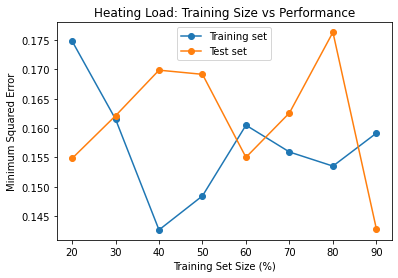

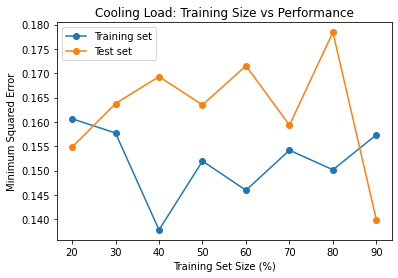

In [ ]:
plt.plot(dataFrame['Training Size'], dataFrame['Y1 train error'], 'o-', label =(f'Training set'))
plt.plot(dataFrame['Training Size'], dataFrame['Y1 test error'], 'o-',label =(f'Test set'))
plt.legend()
plt.xlabel('Training Set Size (%)')
plt.ylabel('Minimum Squared Error')
plt.title('Heating Load: Training Size vs Performance')
plt.show()

plt.plot(dataFrame['Training Size'], dataFrame['Y2 train error'], 'o-', label =(f'Training set'))
plt.plot(dataFrame['Training Size'], dataFrame['Y2 test error'], 'o-', label =(f'Test set'))
plt.legend()
plt.xlabel('Training Set Size (%)')
plt.ylabel('Minimum Squared Error')
plt.title('Cooling Load: Training Size vs Performance')
plt.show()

In [ ]:
import time

i = 0
execution_time = 0

while i < 10:

    modelx = LinearRegression()

    start_time = time.perf_counter()

    modelx.fit(x_train, y_train)

    end_time = time.perf_counter()
    execution_time += end_time - start_time
    i += 1

print(f"The execution time is: {execution_time/10}")


The execution time is: 0.00038348379994204154


<ipython-input-41-6ffa33a5784e>:14: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  self.w = np.linalg.lstsq(x, y)[0]          #return w for the least square difference


### Implement Linear Regression with Mini-batch Gradient Descent

In [ ]:
class MiniBatchGradientDescent:

  def __init__(self, learning_rate=.01, max_iters=1e5, epsilon=1e-3, batch_size=32, record_history=False, track_error=False):
        self.learning_rate = learning_rate
        self.max_iters = max_iters
        self.record_history = record_history
        self.track_error = track_error
        self.epsilon = epsilon
        self.batch_size = batch_size
        if record_history:
            self.w_history = []

  def create_mini_batches(self, x, y):
    assert x.shape[0] == y.shape[0]
    indices = np.arange(x.shape[0])
    np.random.shuffle(indices)
    minibatches = []
    for start_idx in range(0, x.shape[0] - self.batch_size + 1, self.batch_size):
        end_idx = min(start_idx + self.batch_size, x.shape[0])
        excerpt = indices[start_idx:end_idx]
        minibatches.append((x[excerpt], y[excerpt]))
    return minibatches

  def hypothesis(self, x, w):
        yh = x@ w                             #predict the y values
        return yh

  def run(self, gradient, X, y, w):
    error_list1 = []
    error_list2 = []
    grad = np.inf
    t = 1

    while np.linalg.norm(grad) > self.epsilon and t < self.max_iters:
        #print("g = ", grad)
        #print(np.linalg.norm(grad))
        mini_batches = self.create_mini_batches(X, y)
        for mini_batch in mini_batches:
            X_mini, y_mini = mini_batch
            w = w - self.learning_rate * gradient(X_mini, y_mini, w)

        if self.record_history:
            self.w_history.append(w)


        if self.track_error:
          error = mse(y, self.hypothesis(X, w))

          error_list1.append([t, error[0]])
          error_list2.append([t, error[1]])

        grad = gradient(X, y, w)
        t += 1
    return w, t, error_list1, error_list2

class LinearRegression2:
  def __init__(self, add_bias=True):
    self.add_bias = add_bias
    pass

  def fit(self, x, y, optimizer):
      if x.ndim == 1:
        x = x[:, None]                       #add a dimension for the features

      if y.ndim == 1:
        y = y[:, None]                       #add a dimension for the features

      if self.add_bias:
          N = x.shape[0]
          x = np.column_stack([x,np.ones(N)])    #add bias by adding a constant feature of value 1

      N,D = x.shape
      Ny,Dy = y.shape
      def gradient(x, y, w):                          # define the gradient function
          yh =  x @ w
          N, D = x.shape
          grad = np.dot(x.T, yh - y)/N
          return grad


      w0 = np.zeros((D, Dy))
      #w0 = w0[:, None]                                # initialize the weights to 0
      self.w, self.iterations, self.training_errors_y1, self.training_errors_y2 = optimizer.run(gradient, x, y, w0)      # run the optimizer to get the optimal weights
      return self

  def predict(self, x):
        #print(x)
        if self.add_bias:
            N = x.shape[0]
            x = np.column_stack([x,np.ones(N)])

        yh = x@self.w                             #predict the y values
        #yh = np.dot(x, self.w)
        #print(yh)
        return yh

In [ ]:
optimizer = MiniBatchGradientDescent(learning_rate=.005, record_history=True)
model = LinearRegression2()
trained_model = model.fit(x_train, y_train, optimizer)
yh_train = trained_model.predict(x_train)


yh_test = trained_model.predict(x_test)
# Calculate the error of training set
mse_train = mse(y_train, yh_train)

# Calculate the error of test set
mse_test = mse(y_test, yh_test)

# Report performance of linear regression
print(mse_train)
print(mse_test)

# Report weights of features
print(trained_model.w)


[0.15906075 0.15724165]
[0.14314303 0.13967923]
[[-0.58870501 -0.69513437]
 [-0.29906246 -0.33281264]
 [ 0.08145525  0.01202048]
 [-0.33096676 -0.33034381]
 [ 0.77802496  0.86352233]
 [-0.00106154 -0.00129429]]


In [ ]:
epsilon_sizes = [1e-2, 1e-3, 1e-4]

epsilon_size_data = []

for i in epsilon_sizes:
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

    optimizer = MiniBatchGradientDescent(epsilon=i, record_history=True)
    model = LinearRegression2()
    trained_model = model.fit(x_train, y_train, optimizer)
    iterations = trained_model.iterations

    yh_train = trained_model.predict(x_train)
    yh_test = trained_model.predict(x_test)
    mse_train = mse(y_train, yh_train)
    mse_test = mse(y_test, yh_test)
    epsilon_size_data.append([i, mse_train[0], mse_train[1], mse_test[0], mse_test[1], iterations])

dataFrame = pd.DataFrame(epsilon_size_data, columns=['Epsilon size', 'Y1 train error', 'Y2 train error', 'Y1 test error', 'Y2 test error', 'Iterations'])
dataFrame

,Epsilon size,Y1 train error,Y2 train error,Y1 test error,Y2 test error,Iterations
0,0.0100,0.153312,0.158177,0.187084,0.158938,192
1,0.0010,0.151600,0.155885,0.181338,0.153721,2357
2,0.0001,0.151575,0.155849,0.181128,0.153415,100000


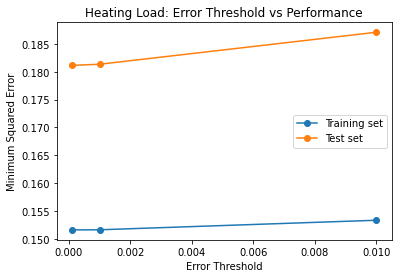

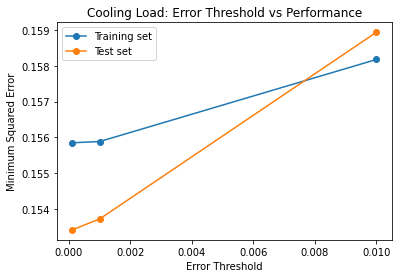

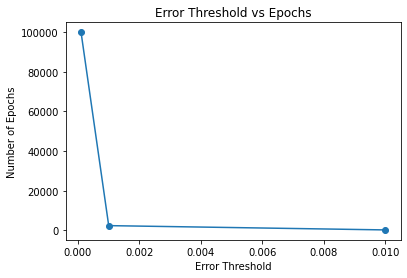

In [ ]:
plt.plot(dataFrame['Epsilon size'], dataFrame['Y1 train error'], 'o-', label =(f'Training set'))
plt.plot(dataFrame['Epsilon size'], dataFrame['Y1 test error'], 'o-',label =(f'Test set'))
plt.legend()
plt.xlabel('Error Threshold')
plt.ylabel('Minimum Squared Error')
plt.title('Heating Load: Error Threshold vs Performance')
plt.show()

plt.plot(dataFrame['Epsilon size'], dataFrame['Y2 train error'], 'o-', label =(f'Training set'))
plt.plot(dataFrame['Epsilon size'], dataFrame['Y2 test error'], 'o-', label =(f'Test set'))
plt.legend()
plt.xlabel('Error Threshold')
plt.ylabel('Minimum Squared Error')
plt.title('Cooling Load: Error Threshold vs Performance')
plt.show()

plt.plot(dataFrame['Epsilon size'], dataFrame['Iterations'], 'o-')
plt.xlabel('Error Threshold')
plt.ylabel('Number of Epochs')
plt.title('Error Threshold vs Epochs')
plt.show()


In [ ]:
batch_sizes = [8, 16, 32, 64, 128]

batch_size_data = []
batch_size_training_data_y1 = []
batch_size_training_data_y2 = []

for i in batch_sizes:
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

    optimizer = MiniBatchGradientDescent(learning_rate=.005, batch_size = i, record_history=True, track_error=True)
    model = LinearRegression2()
    trained_model = model.fit(x_train, y_train, optimizer)
    iterations = trained_model.iterations

    yh_train = trained_model.predict(x_train)
    yh_test = trained_model.predict(x_test)
    mse_train = mse(y_train, yh_train)
    mse_test = mse(y_test, yh_test)
    batch_size_data.append([i, mse_train[0], mse_train[1], mse_test[0], mse_test[1], iterations])

    batch_size_training_data_y1.append([i, trained_model.training_errors_y1])
    batch_size_training_data_y2.append([i, trained_model.training_errors_y2])

dataFrame = pd.DataFrame(batch_size_data, columns=['Batch size', 'Y1 train error', 'Y2 train error', 'Y1 test error', 'Y2 test error', 'Iterations'])
dataFrame

,Batch size,Y1 train error,Y2 train error,Y1 test error,Y2 test error,Iterations
0,8,0.151571,0.155848,0.181150,0.153470,3540
1,16,0.151619,0.155909,0.181389,0.153804,2044
2,32,0.151643,0.155939,0.181444,0.153896,3591
3,64,0.151649,0.155947,0.181444,0.153905,7422
4,128,0.151641,0.155938,0.181482,0.153897,17137


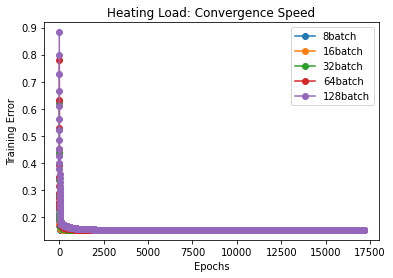

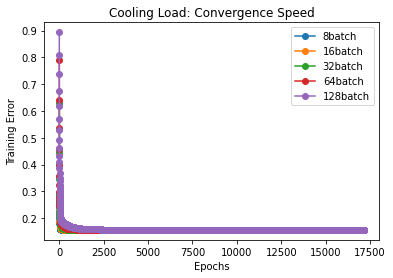

In [ ]:
for x in batch_size_training_data_y1:

    dataFrame2 = pd.DataFrame(x[1], columns=['Epochs', 'Training Error'])
    #print(dataFrame2['Training Error'])
    plt.plot(dataFrame2['Epochs'], dataFrame2['Training Error'], 'o-', label=(str(x[0]) + 'batch'))

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Training Error')
plt.title('Heating Load: Convergence Speed')
plt.show()

for x in batch_size_training_data_y2:

    dataFrame2 = pd.DataFrame(x[1], columns=['Epochs', 'Training Error'])
    #print(dataFrame2['Training Error'])
    plt.plot(dataFrame2['Epochs'], dataFrame2['Training Error'], 'o-', label=(str(x[0]) + 'batch'))

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Training Error')
plt.title('Cooling Load: Convergence Speed')
plt.show()

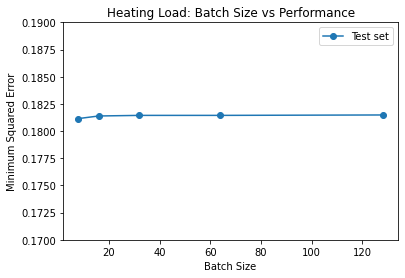

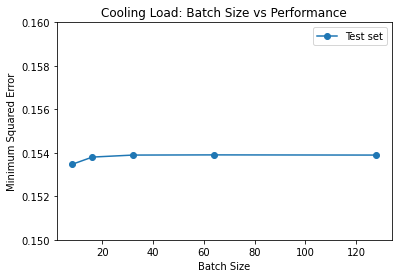

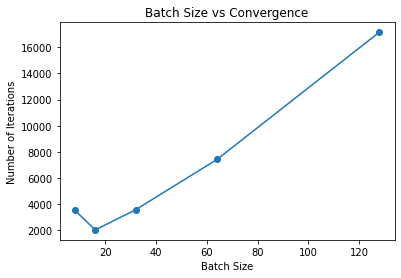

In [ ]:
"""plt.plot(dataFrame['Batch size'], dataFrame['Y1 train error'], 'o-', label =(f'Training set'))
plt.plot(dataFrame['Batch size'], dataFrame['Y1 test error'], 'o-',label =(f'Test set'))
plt.legend()
#plt.ylim(0,0.02)
plt.xlabel('Batch Size')
plt.ylabel('Minimum Squared Error')
plt.title('Batch Size vs Performance')
plt.show()"""

plt.plot(dataFrame['Batch size'], dataFrame['Y1 test error'], 'o-',label =(f'Test set'))
plt.legend()
plt.ylim(0.17,0.19)
plt.xlabel('Batch Size')
plt.ylabel('Minimum Squared Error')
plt.title('Heating Load: Batch Size vs Performance')
plt.show()

"""plt.plot(dataFrame['Batch size'], dataFrame['Y2 train error'], 'o-', label =(f'Y2 training set'))
plt.plot(dataFrame['Batch size'], dataFrame['Y2 test error'], 'o-', label =(f'Y2 test set'))
plt.legend()
#plt.ylim(0,0.02)
plt.xlabel('Batch Size')
plt.ylabel('Minimum Squared Error')
plt.title('Batch Size vs Performance')
plt.show()"""

plt.plot(dataFrame['Batch size'], dataFrame['Y2 test error'], 'o-', label =(f'Test set'))
plt.legend()
plt.ylim(0.15,0.16)
plt.xlabel('Batch Size')
plt.ylabel('Minimum Squared Error')
plt.title('Cooling Load: Batch Size vs Performance')
plt.show()

plt.plot(dataFrame['Batch size'], dataFrame['Iterations'], 'o-')
#plt.ylim(0,0.02)
plt.xlabel('Batch Size')
plt.ylabel('Number of Iterations')
plt.title('Batch Size vs Convergence')
plt.show()

In [ ]:
learning_rates = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.007, 0.008, 0.009, 0.01]

learning_rates_data = []

for i in learning_rates:
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

    optimizer = MiniBatchGradientDescent(learning_rate=i, batch_size=32, record_history=True)
    model = LinearRegression2()
    trained_model = model.fit(x_train, y_train, optimizer)
    iterations = trained_model.iterations

    yh_train = trained_model.predict(x_train)
    yh_test = trained_model.predict(x_test)
    mse_train = mse(y_train, yh_train)
    mse_test = mse(y_test, yh_test)
    learning_rates_data.append([i, mse_train[0], mse_train[1], mse_test[0], mse_test[1], iterations])

dataFrame = pd.DataFrame(learning_rates_data, columns=['Learning rate', 'Y1 train error', 'Y2 train error', 'Y1 test error', 'Y2 test error', 'Iterations'])
dataFrame

,Learning rate,Y1 train error,Y2 train error,Y1 test error,Y2 test error,Iterations
0,0.001,0.151669,0.155973,0.181528,0.153981,16142
1,0.002,0.151665,0.155968,0.181519,0.153962,8209
2,0.003,0.151669,0.155972,0.181517,0.153979,5394
3,0.004,0.151657,0.155958,0.181511,0.153939,4236
4,0.005,0.151652,0.155951,0.181487,0.153924,3469
5,0.006,0.151657,0.155957,0.181506,0.153937,2826
6,0.007,0.151642,0.155938,0.181448,0.153895,2593
7,0.007,0.151629,0.155922,0.181410,0.153845,2751
8,0.008,0.151636,0.155931,0.181427,0.153849,2322
9,0.009,0.151635,0.155930,0.181468,0.153875,2077


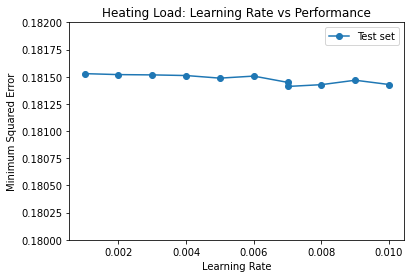

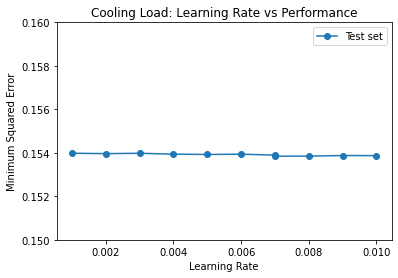

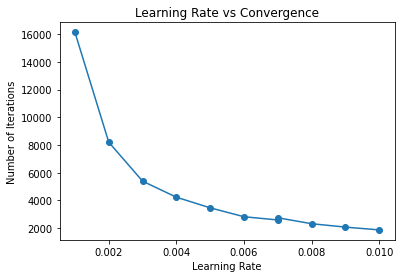

In [ ]:
"""plt.plot(dataFrame['Learning rate'], dataFrame['Y1 train error'], 'o-', label =(f'Y1 training set'))
plt.plot(dataFrame['Learning rate'], dataFrame['Y1 test error'], 'o-',label =(f'Y1 test set'))
plt.legend()
#plt.ylim(0,0.02)
plt.xlabel('Learning Rate')
plt.ylabel('Minimum Squared Error')
plt.title('Learning Rate vs Performance')
plt.show()"""

plt.plot(dataFrame['Learning rate'], dataFrame['Y1 test error'], 'o-',label =(f'Test set'))
plt.legend()
plt.ylim(0.18,0.182)
plt.xlabel('Learning Rate')
plt.ylabel('Minimum Squared Error')
plt.title('Heating Load: Learning Rate vs Performance')
plt.show()

"""plt.plot(dataFrame['Learning rate'], dataFrame['Y2 train error'], 'o-', label =(f'Y2 training set'))
plt.plot(dataFrame['Learning rate'], dataFrame['Y2 test error'], 'o-', label =(f'Y2 test set'))
plt.legend()
#plt.ylim(0,0.02)
plt.xlabel('Learning Rate')
plt.ylabel('Minimum Squared Error')
plt.title('Learning Rate vs Performance')
plt.show()"""

plt.plot(dataFrame['Learning rate'], dataFrame['Y2 test error'], 'o-', label =(f'Test set'))
plt.legend()
plt.ylim(0.15,0.16)
plt.xlabel('Learning Rate')
plt.ylabel('Minimum Squared Error')
plt.title('Cooling Load: Learning Rate vs Performance')
plt.show()

plt.plot(dataFrame['Learning rate'], dataFrame['Iterations'], 'o-')
#plt.ylim(0,0.02)
plt.xlabel('Learning Rate')
plt.ylabel('Number of Iterations')
plt.title('Learning Rate vs Convergence')
plt.show()

In [ ]:
import time

i = 0
execution_time = 0
while i < 10:
    modelx = LinearRegression2()
    optimizer = MiniBatchGradientDescent(learning_rate=0.01, batch_size=32, record_history=True)

    start_time = time.perf_counter()

    modelx.fit(x_train, y_train, optimizer)

    end_time = time.perf_counter()
    execution_time += end_time - start_time
    i += 1
print(f"The execution time is: {execution_time/10}")

The execution time is: 0.7341570765999222


# Data Set 2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

# from sklearn import preprocessing
import matplotlib.pyplot as plt
plt.rc("font", size=14)
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)


##Task 1: Acquire, preprocess and analyze data

####Step 1 : Load the dataset2 into NumPy project in Python.

In [ ]:
column_names = ['IR', 'MR', 'FF', 'CR', 'CO', 'OP', 'Class']
data2 = pd.read_csv(DATA_DIR / "qualitative_bankruptcy_data.txt", header=None)
data2.columns = column_names
data2.head(10)

,IR,MR,FF,CR,CO,OP,Class
0,P,P,A,A,A,P,NB
1,N,N,A,A,A,N,NB
2,A,A,A,A,A,A,NB
3,P,P,P,P,P,P,NB
4,N,N,P,P,P,N,NB
5,A,A,P,P,P,A,NB
6,P,P,A,P,P,P,NB
7,P,P,P,A,A,P,NB
8,P,P,A,P,A,P,NB
9,P,P,A,A,P,P,NB


#### Step 2 : Clean the data.

In [ ]:
print("Missing values distribution: ")
print(data2.isnull().sum())

Missing values distribution: 
IR       0
MR       0
FF       0
CR       0
CO       0
OP       0
Class    0
dtype: int64


In [ ]:
attributeDict = {'P': 0, 'A': 1, 'N': 2}
classDict  = {'NB': 0, 'B': 1}
data2['Class'] = data2['Class'].map(classDict)
data2['IR'] = data2['IR'].map(attributeDict)
data2['MR'] = data2['MR'].map(attributeDict)
data2['FF'] = data2['FF'].map(attributeDict)
data2['CR'] = data2['CR'].map(attributeDict)
data2['CO'] = data2['CO'].map(attributeDict)
data2['OP'] = data2['OP'].map(attributeDict)
print(data2.head(200))

     IR  MR  FF  CR  CO  OP  Class
0     0   0   1   1   1   0      0
1     2   2   1   1   1   2      0
2     1   1   1   1   1   1      0
3     0   0   0   0   0   0      0
4     2   2   0   0   0   2      0
..   ..  ..  ..  ..  ..  ..    ...
195   2   0   2   2   2   2      1
196   1   0   2   1   2   2      1
197   2   2   2   2   2   2      1
198   2   2   2   1   2   1      1
199   2   2   2   0   2   2      1

[200 rows x 7 columns]


In [ ]:
for i,j in zip(data2.columns,(data2.values.astype(str) == '?').sum(axis = 0)):
    if j > 0:
        print(str(i) + ': ' + str(j) + ' missing')

#### Step 3: Basic Statistics

In [ ]:
from collections import Counter

print(Counter(data2['Class']))

Counter({0: 143, 1: 107})


In [ ]:
pd.DataFrame(data2.describe()).rename(columns={'IR':'Industrial Risk',
                                               'MR': 'Management Risk',
                                               'FF': 'Financial Flexibility"',
                                               'CR': 'Credibility',
                                               'CO': 'Competitiveness',
                                               'OR': 'Operating Risk',
                                               'Class': 'Class'})


,Industrial Risk,Management Risk,"Financial Flexibility""",Credibility,Competitiveness,OP,Class
count,250.000000,250.00000,250.000000,250.000000,250.000000,250.00000,250.000000
mean,1.036000,1.22800,1.248000,1.060000,1.048000,1.14000,0.428000
std,0.823051,0.82141,0.803166,0.831363,0.881364,0.86915,0.495781
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,0.000000,1.00000,1.000000,0.000000,0.000000,0.00000,0.000000
50%,1.000000,1.00000,1.000000,1.000000,1.000000,1.00000,0.000000
75%,2.000000,2.00000,2.000000,2.000000,2.000000,2.00000,1.000000
max,2.000000,2.00000,2.000000,2.000000,2.000000,2.00000,1.000000


## Task 2: Implement Logistic Regression

In [ ]:
logistic = lambda z: (1./ (1 + np.exp(-z)))     #logistic function

In [ ]:
def compute_cost_logistic(X, y, w, b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(X[i],w) + b
        f_wb_i = logistic(z_i)
        cost +=  -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)

    cost = cost / m
    return cost

In [ ]:
def gradient(self, x, y):
    N,D = x.shape
    yh = logistic(np.dot(x, self.w))    # predictions  size N
    grad = np.dot(x.T, yh - y)/N        # divide by N because cost is mean over N points
    return grad                         # size D


In [ ]:
class LogisticRegression:

    def __init__(self, add_bias=True, learning_rate=.1, epsilon=1e-4, max_iters=1e5, verbose=False):
        self.add_bias = add_bias
        self.learning_rate = learning_rate
        self.epsilon = epsilon                        #to get the tolerance for the norm of gradients
        self.max_iters = max_iters                    #maximum number of iteration of gradient descent
        self.verbose = verbose


    def fit(self, x, y):
        if x.ndim == 1:
            x = x[:, None]
        if self.add_bias:
            N = x.shape[0]
            x = np.column_stack([x,np.ones(N)])
        N,D = x.shape
        self.w = np.zeros(D)
        g = np.inf
        t = 0
        # the code snippet below is for gradient descent
        while np.linalg.norm(g) > self.epsilon and t < self.max_iters:
            g = self.gradient(x, y)
            self.w = self.w - self.learning_rate * g
            t += 1

        if self.verbose:
            print(f'terminated after {t} iterations, with norm of the gradient equal to {np.linalg.norm(g)}')
            print(f'the weight found: {self.w}')
        return self

    def predict(self, x):
        if x.ndim == 1:
            x = x[:, None]
        Nt = x.shape[0]
        if self.add_bias:
            x = np.column_stack([x,np.ones(Nt)])
        yh = logistic(np.dot(x,self.w))            #predict output
        return yh

    def cost_fn(self, x, y, w):
      N, D = x.shape
      z = np.dot(x, w)
      J = np.mean(y * np.log1p(np.exp(-z)) + (1-y) * np.log1p(np.exp(z)))  #log1p calculates log(1+x) to remove floating point inaccuracies
      return J

LogisticRegression.gradient = gradient             #initialize the gradient method of the LogisticRegression class with gradient function


In [ ]:
def accuracy(y_true, y_pred):
    correct = 0
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            correct += 1
    return correct / len(y_true)

## Task 3: Run Logistic Regression Analysis on the Data

#### Step 1 : Fully Batched Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split

# get x and y
x = np.array([data2['IR'], data2['MR'], data2['FF'], data2['CR'], data2['CO'], data2['OP']])
y = np.array(data2['Class'])
x = x.T
y = y.T

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LogisticRegression()
trained_model = model.fit(X_train,y_train)
yh_train = trained_model.predict(X_train)
yh_test = trained_model.predict(X_test)

Report the performace of fully batched logistic regression.

In [ ]:
cost_train = compute_cost_logistic(X_train, y_train, trained_model.w[0:6],trained_model.w[-1])
print("The cost for the train data is: ", cost_train)
cost_test = compute_cost_logistic(X_test, y_test, trained_model.w[0:6],trained_model.w[-1])
print("The cost for the test data is: ", cost_test)

acc_train = accuracy(y_train, np.round(yh_train))
print("The accuracy for the train data is: ", acc_train)
acc_test = accuracy(y_test, np.round(yh_test))
print("The accuracy for the test data is: ", acc_test)

The cost for the train data is:  0.005509808152488845
The cost for the test data is:  0.0006636566056713897
The accuracy for the train data is:  1.0
The accuracy for the test data is:  1.0


#### Step 2 : Calculate the weights of each features in the trained models

In [ ]:
for i in range(1,7):
  print("w"+str(i)," : ", trained_model.w[i-1])
print("b : ", trained_model.w[6])

w1  :  -0.16367785162995058
w2  :  0.013711075148131432
w3  :  3.270511703886556
w4  :  3.085287513606897
w5  :  9.57891935300001
w6  :  0.3186102178951937
b :  -20.154363847925016


Dicuss how each future could affect the performance of the models.

The feature w4 effects most, at the same time, w5 does not effects much.

####Step 3 : Sample growing subsets of training data

In [ ]:
def accuracy(y_true, y_pred):
    correct = 0
    for i in range(len(y_true)):
        if y_true[i] == y_pred[i]:
            correct += 1
    return correct / len(y_true)

In [ ]:
i = 0.9

train_size_data = []

while i >= 0.1:
    # Split data into training (50%) and testing (50%) sets
    X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=i, random_state=0)

    subsets_model = LogisticRegression()
    subsets_model = model.fit(X_train, y_train)

    yh_train = subsets_model.predict(X_train)
    yh_test = subsets_model.predict(X_test)

    cost_train = compute_cost_logistic(X_train, y_train, subsets_model.w[0:6],subsets_model.w[-1])
    cost_test = compute_cost_logistic(X_test, y_test, subsets_model.w[0:6],subsets_model.w[-1])
    acc_train = accuracy(y_train, np.round(yh_train))
    acc_test = accuracy(y_test, np.round(yh_test))
    train_size_data.append([(1-i)*100, cost_train, cost_test, acc_train, acc_test])
    i -= 0.1

dataFrame = pd.DataFrame(train_size_data,
                         columns=['Training Size(%)', 'Train Error', 'Test Error', 'Train Accuracy', 'Test Accuracy'])
dataFrame



,Training Size(%),Train Error,Test Error,Train Accuracy,Test Accuracy
0,10.0,0.003356,0.051444,1.0,0.982222
1,20.0,0.002708,0.038240,1.0,0.985000
2,30.0,0.002551,0.030857,1.0,0.994318
3,40.0,0.002485,0.037600,1.0,0.993377
4,50.0,0.005352,0.007158,1.0,1.000000
5,60.0,0.005409,0.006341,1.0,1.000000
6,70.0,0.005547,0.002854,1.0,1.000000
7,80.0,0.005202,0.003187,1.0,1.000000
8,90.0,0.004956,0.004788,1.0,1.000000


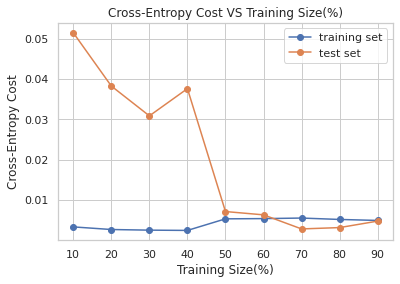

In [ ]:
import matplotlib.pyplot as plt

plt.plot(dataFrame['Training Size(%)'], dataFrame['Train Error'], 'o-', label =(f'training set'))
plt.plot(dataFrame['Training Size(%)'], dataFrame['Test Error'], 'o-',label =(f'test set'))

plt.xlabel('Training Size(%)')
plt.ylabel('Cross-Entropy Cost')
plt.title('Cross-Entropy Cost VS Training Size(%)')
plt.legend()
plt.show()


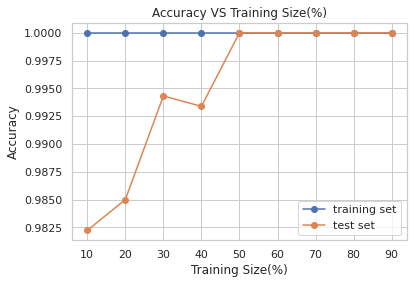

In [ ]:
# This is the line graph for all the data
plt.plot(dataFrame['Training Size(%)'], dataFrame['Train Accuracy'], 'o-', label =(f'training set'))
plt.plot(dataFrame['Training Size(%)'], dataFrame['Test Accuracy'], 'o-',label =(f'test set'))

plt.xlabel('Training Size(%)')
plt.ylabel('Accuracy')
plt.title('Accuracy VS Training Size(%)')
plt.legend()
plt.show()

####Step 4 : mini-batch stochastic gradient descent

In [ ]:
class LogisticRegressionMiniBatch:

    def __init__(self, add_bias=True, learning_rate=.1, epsilon=1e-4, max_iters=1e5, verbose=False, batch_size=32):
        self.add_bias = add_bias
        self.learning_rate = learning_rate
        self.epsilon = epsilon                        #to get the tolerance for the norm of gradients
        self.max_iters = int(max_iters)                    #maximum number of iteration of gradient descent
        self.verbose = verbose
        self.batch_size = batch_size
        self.t_lst = []
        self.cost_lst = []

    def fit(self, x, y):
        if x.ndim == 1:
            x = x[:, None]
        if self.add_bias:
            N = x.shape[0]
            x = np.column_stack([x,np.ones(N)])
        N,D = x.shape
        self.w = np.zeros(D)
        for t in range(self.max_iters):
            permuted_idx = np.random.permutation(N)
            x_shuffled = x[permuted_idx]
            y_shuffled = y[permuted_idx]
            for i in range(0, N, self.batch_size):
                x_batch = x_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]
                g = self.gradient(x_batch, y_batch)
                self.w = self.w - self.learning_rate * g

            if (t % self.batch_size) == 0:
                self.t_lst.append(t)
                cost = self.compute_cost_logistic(x, y, self.w)
                self.cost_lst.append(cost)

            if self.verbose:
                cost = self.compute_cost_logistic(x, y, self.w)
                print(f'iteration: {t}, cost: {cost}')

        if self.verbose:
            print(f'terminated after {t} iterations, with norm of the gradient equal to {np.linalg.norm(g)}')
            print(f'the weight found: {self.w}')
        return self

    def predict(self, x):
        if x.ndim == 1:
            x = x[:, None]
        Nt = x.shape[0]
        if self.add_bias:
            x = np.column_stack([x,np.ones(Nt)])
        yh = logistic(np.dot(x,self.w))            #predict output
        return yh

    def compute_cost_logistic(self, X, y, w):
      m = X.shape[0]
      cost = 0.0
      for i in range(m):
        z_i = np.dot(X[i],w)
        f_wb_i = logistic(z_i)
        cost +=  -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)

      cost = cost / m
      return cost

LogisticRegressionMiniBatch.gradient = gradient             #initialize the gradient method of the LogisticRegression class with gradient function


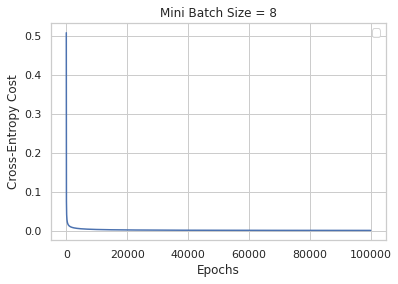

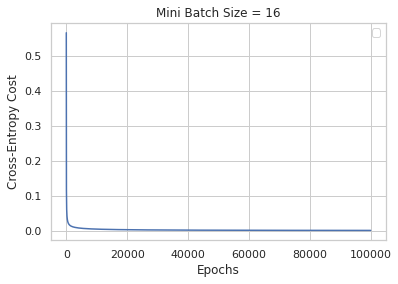

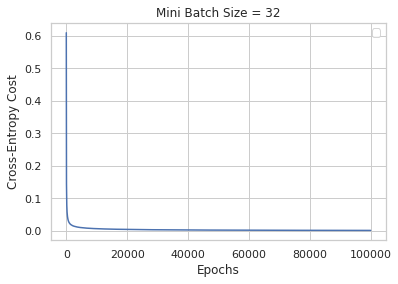

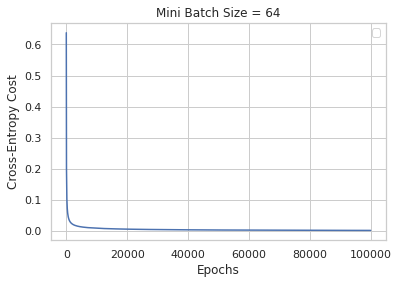

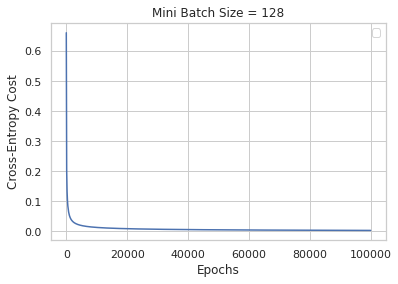

,Mini Batch Size,Train Error,Test Error,Train Accuracy,Test Accuracy
0,8,0.000359,0.000205,1.0,1.0
1,16,0.000664,0.000384,1.0,1.0
2,32,0.001164,0.000691,1.0,1.0
3,64,0.001879,0.001131,1.0,1.0
4,128,0.003230,0.001962,1.0,1.0


In [ ]:
train_miniBatch_data = []
mini_batch_size = [8, 16, 32, 64, 128]

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

for i in mini_batch_size:
  mini_batch_model = LogisticRegressionMiniBatch()
  mini_batch_model.batch_size = i
  mini_batch_model = mini_batch_model.fit(X_train, y_train)

  plt.plot(mini_batch_model.t_lst, mini_batch_model.cost_lst)

  plt.xlabel('Epochs')
  plt.ylabel('Cross-Entropy Cost')
  plt.title('Mini Batch Size = ' + str(i))
  plt.legend()
  plt.show()

  yh_train = mini_batch_model.predict(X_train)
  yh_test = mini_batch_model.predict(X_test)

  cost_train = compute_cost_logistic(X_train, y_train, mini_batch_model.w[0:6],mini_batch_model.w[-1])
  cost_test = compute_cost_logistic(X_test, y_test, mini_batch_model.w[0:6],mini_batch_model.w[-1])
  acc_train = accuracy(y_train, np.round(yh_train))
  acc_test = accuracy(y_test, np.round(yh_test))

  train_miniBatch_data.append([i, cost_train, cost_test, acc_train, acc_test])

dataFrame = pd.DataFrame(train_miniBatch_data, columns=['Mini Batch Size', 'Train Error', 'Test Error', 'Train Accuracy', 'Test Accuracy'])
dataFrame


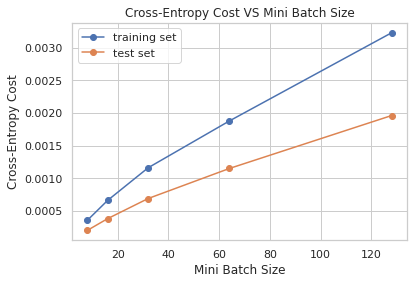

In [ ]:
plt.plot(dataFrame['Mini Batch Size'], dataFrame['Train Error'], 'o-', label =(f'training set'))
plt.plot(dataFrame['Mini Batch Size'], dataFrame['Test Error'], 'o-',label =(f'test set'))

plt.xlabel('Mini Batch Size')
plt.ylabel('Cross-Entropy Cost')
plt.title('Cross-Entropy Cost VS Mini Batch Size')
plt.legend()
plt.show()



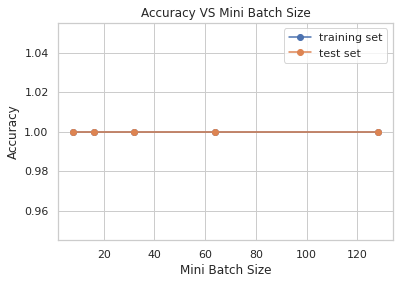

In [ ]:
plt.plot(dataFrame['Mini Batch Size'], dataFrame['Train Accuracy'], 'o-', label =(f'training set'))
plt.plot(dataFrame['Mini Batch Size'], dataFrame['Test Accuracy'], 'o-',label =(f'test set'))

plt.xlabel('Mini Batch Size')
plt.ylabel('Accuracy')
plt.title('Accuracy VS Mini Batch Size')
plt.legend()
plt.show()

####Step 5 : Performance of different learning rates

In [ ]:
train_learningRate_data = []
learning_rates = [0.00001, 0.00003, 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
learning_rate_model = LogisticRegression()

for i in learning_rates:
  # change of learning rate of the model
  learning_rate_model.learning_rate = i
  learning_rate_model = learning_rate_model.fit(X_train, y_train)

  yh_train = learning_rate_model.predict(X_train)
  yh_test = learning_rate_model.predict(X_test)

  cost_train = compute_cost_logistic(X_train, yh_train, learning_rate_model.w[0:6],learning_rate_model.w[-1])
  cost_test = compute_cost_logistic(X_test, yh_test, learning_rate_model.w[0:6],learning_rate_model.w[-1])

  acc_train = accuracy(y_train, np.round(yh_train))
  acc_test = accuracy(y_test, np.round(yh_test))
  train_learningRate_data.append([i, cost_train, cost_test, acc_train, acc_test])

dataFrame = pd.DataFrame(train_learningRate_data,
                         columns=['Learning Rate', 'Train Error', 'Test Error', 'Train Accuracy', 'Test Accuracy'])
dataFrame

,Learning Rate,Train Error,Test Error,Train Accuracy,Test Accuracy
0,0.00001,0.668488,0.668861,0.675,0.66
1,0.00003,0.630284,0.628873,0.835,0.84
2,0.00010,0.516600,0.503786,0.905,0.86
3,0.00030,0.371661,0.351046,0.980,0.98
4,0.00100,0.221247,0.202824,0.995,1.00
5,0.00300,0.122149,0.106329,1.000,1.00
6,0.01000,0.061006,0.049635,1.000,1.00
7,0.03000,0.033408,0.025626,1.000,1.00
8,0.10000,0.018018,0.012987,1.000,1.00


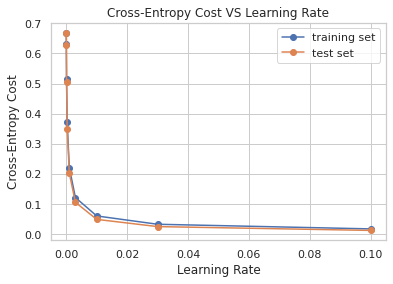

In [ ]:
plt.plot(dataFrame['Learning Rate'], dataFrame['Train Error'], 'o-', label =(f'training set'))
plt.plot(dataFrame['Learning Rate'], dataFrame['Test Error'], 'o-',label =(f'test set'))

plt.xlabel('Learning Rate')
plt.ylabel('Cross-Entropy Cost')
plt.title('Cross-Entropy Cost VS Learning Rate')
plt.legend()
plt.show()

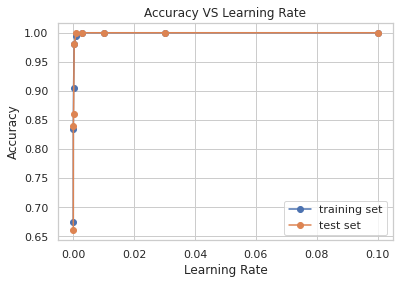

In [ ]:
# This is the line graph for all the data
plt.plot(dataFrame['Learning Rate'], dataFrame['Train Accuracy'], 'o-', label =(f'training set'))
plt.plot(dataFrame['Learning Rate'], dataFrame['Test Accuracy'], 'o-',label =(f'test set'))

plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Accuracy VS Learning Rate')
plt.legend()
plt.show()

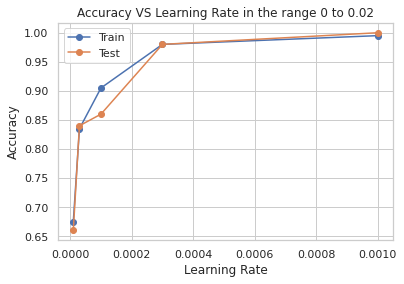

In [ ]:
# see the range of 0.00 and 0.02
learning_rate = dataFrame.iloc[:5, 0]
acc_train = dataFrame.iloc[:5, 3]
acc_test = dataFrame.iloc[:5, 4]

plt.plot(learning_rate, acc_train,'o-', label='Train')
plt.plot(learning_rate, acc_test,'o-', label='Test')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Accuracy VS Learning Rate in the range 0 to 0.02')
plt.legend()
plt.show()


### Performance for different epsilons

In [ ]:
train_epsilon_data = []
epsilons = [0.00001, 0.00005, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
epsilon_model = LogisticRegression()

for i in epsilons:
  # change of learning rate of the model
  epsilon_model.epsilon = i
  epsilon_model = epsilon_model.fit(X_train, y_train)

  yh_train = epsilon_model.predict(X_train)
  yh_test = epsilon_model.predict(X_test)

  cost_train = compute_cost_logistic(X_train, yh_train, epsilon_model.w[0:6],epsilon_model.w[-1])
  cost_test = compute_cost_logistic(X_test, yh_test, epsilon_model.w[0:6],epsilon_model.w[-1])

  acc_train = accuracy(y_train, np.round(yh_train))
  acc_test = accuracy(y_test, np.round(yh_test))
  train_epsilon_data.append([i, cost_train, cost_test, acc_train, acc_test])

dataFrame = pd.DataFrame(train_epsilon_data,
                         columns=['Epsilon', 'Train Error', 'Test Error', 'Train Accuracy', 'Test Accuracy'])
dataFrame

,Epsilon,Train Error,Test Error,Train Accuracy,Test Accuracy
0,0.00001,0.018018,0.012987,1.00,1.00
1,0.00005,0.018018,0.012987,1.00,1.00
2,0.00010,0.018018,0.012987,1.00,1.00
3,0.00050,0.018018,0.012987,1.00,1.00
4,0.00100,0.026558,0.019934,1.00,1.00
5,0.00500,0.079669,0.066551,1.00,1.00
6,0.01000,0.126547,0.110527,1.00,1.00
7,0.05000,0.337800,0.317438,0.99,0.98


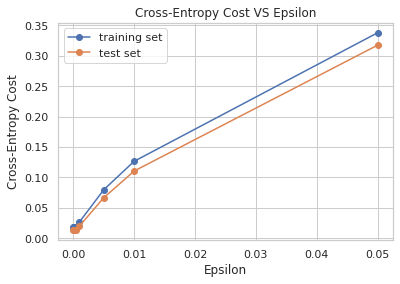

In [ ]:
plt.plot(dataFrame['Epsilon'], dataFrame['Train Error'], 'o-', label =(f'training set'))
plt.plot(dataFrame['Epsilon'], dataFrame['Test Error'], 'o-',label =(f'test set'))

plt.xlabel('Epsilon')
plt.ylabel('Cross-Entropy Cost')
plt.title('Cross-Entropy Cost VS Epsilon')
plt.legend()
plt.show()

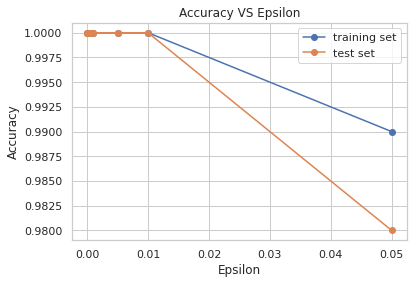

In [ ]:
# This is the line graph for all the data
plt.plot(dataFrame['Epsilon'], dataFrame['Train Accuracy'], 'o-', label =(f'training set'))
plt.plot(dataFrame['Epsilon'], dataFrame['Test Accuracy'], 'o-',label =(f'test set'))

plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.title('Accuracy VS Epsilon')
plt.legend()
plt.show()

### Performance for different maximum iterations

In [ ]:
train_max_iters_data = []
max_iters = [100, 1000,10000, 50000, 100000, 500000, 1000000]

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
max_iters_model = LogisticRegression()

for i in max_iters:
  # change of learning rate of the model
  max_iters_model.max_iters = i
  max_iters_model = max_iters_model.fit(X_train, y_train)

  yh_train = max_iters_model.predict(X_train)
  yh_test = max_iters_model.predict(X_test)

  cost_train = compute_cost_logistic(X_train, yh_train, max_iters_model.w[0:6],max_iters_model.w[-1])
  cost_test = compute_cost_logistic(X_test, yh_test, max_iters_model.w[0:6],max_iters_model.w[-1])
  acc_train = accuracy(y_train, np.round(yh_train))
  acc_test = accuracy(y_test, np.round(yh_test))

  train_max_iters_data.append([i, cost_train, cost_test, acc_train, acc_test])

dataFrame = pd.DataFrame(train_max_iters_data,
                         columns=['Max Iterations', 'Train Error', 'Test Error', 'Train Accuracy', 'Test Accuracy'])
dataFrame


,Max Iterations,Train Error,Test Error,Train Accuracy,Test Accuracy
0,100,0.515890,0.503011,0.905,0.86
1,1000,0.221133,0.202712,0.995,1.00
2,10000,0.061000,0.049629,1.000,1.00
3,50000,0.025663,0.019198,1.000,1.00
4,100000,0.018018,0.012987,1.000,1.00
5,500000,0.007024,0.004618,1.000,1.00
6,1000000,0.004781,0.003065,1.000,1.00
